**Ejemplo simple en Python**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

| Paso | Capa                     | Qué hace                                     | Resultado                        |
| ---- | ------------------------ | -------------------------------------------- | -------------------------------- |
| 1    | **Input (64x64x3)**      | Recibe la imagen RGB                         | Píxeles originales               |
| 2    | **Conv2D (32)**          | Detecta bordes, líneas y colores             | Mapas de características básicas |
| 3    | **MaxPooling**           | Reduce tamaño y mantiene lo importante       | Imagen más pequeña y resumida    |
| 4    | **Conv2D (64)**          | Detecta texturas y patrones más complejos    | Features más elaboradas          |
| 5    | **MaxPooling**           | Reduce nuevamente la dimensionalidad         | Información más compacta         |
| 6    | **Conv2D (64)**          | Detecta formas y partes de objetos           | Representación de alto nivel     |
| 7    | **Flatten**              | Convierte la matriz en vector 1D             | Datos listos para clasificación  |
| 8    | **Dense (64)**           | Combina características y aprende relaciones | Representación para decisión     |
| 9    | **Dense (10 + softmax)** | Clasifica en 10 categorías                   | Probabilidades por clase         |


**Demo en Python de una convolución simple**

Imagen original:
[[10 10 10 10 10]
 [10 50 50 50 10]
 [10 50 90 50 10]
 [10 50 50 50 10]
 [10 10 10 10 10]]

Filtro:
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

Resultado de la convolución:
[[-120 -160 -120]
 [   0    0    0]
 [ 120  160  120]]


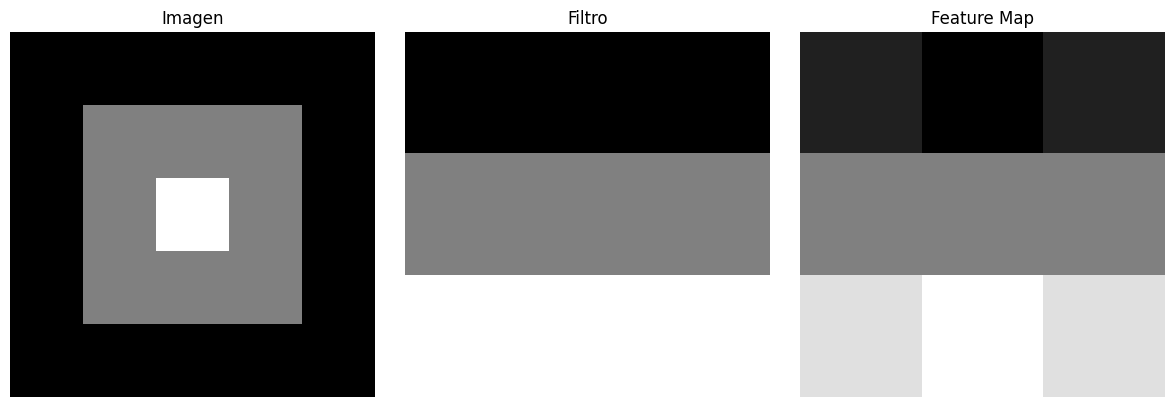

In [ ]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

# Imagen simple 5x5
imagen = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 90, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
])

# Filtro para detectar cambios horizontales
filtro = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

# Aplicar convolución
resultado = convolve2d(imagen, filtro, mode='valid')

print("Imagen original:")
print(imagen)

print("\nFiltro:")
print(filtro)

print("\nResultado de la convolución:")
print(resultado)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(imagen, cmap='gray')
axes[0].set_title("Imagen")
axes[0].axis("off")

axes[1].imshow(filtro, cmap='gray')
axes[1].set_title("Filtro")
axes[1].axis("off")

axes[2].imshow(resultado, cmap='gray')
axes[2].set_title("Feature Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Script completo CNN con CIFAR-10**

CIFAR-10 es un dataset de imágenes pequeñas que contiene 10 categorías de objetos como animales y vehículos. Se utiliza ampliamente para entrenar modelos de visión por computador, ya que permite evaluar la capacidad de una red neuronal para reconocer patrones visuales en imágenes reales.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


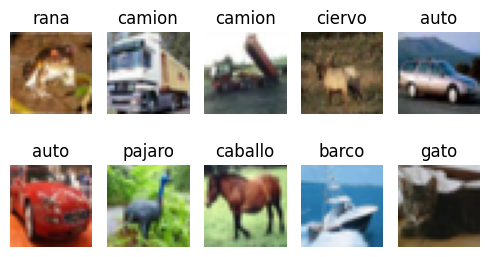

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'avion', 'auto', 'pajaro', 'gato', 'ciervo',
    'perro', 'rana', 'caballo', 'barco', 'camion'
]

# 2. Normalizar imágenes
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Mostrar algunas imágenes
plt.figure(figsize=(5, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# 4. Definir modelo CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

| Capa                | Tipo             | Output Shape | Qué hace                                         | Por qué está ahí                                                          |
| ------------------- | ---------------- | ------------ | ------------------------------------------------ | ------------------------------------------------------------------------- |
| **conv2d_6**        | Convolución      | (30, 30, 32) | Aplica 32 filtros 3×3 sobre la imagen            | Detecta patrones visuales simples como bordes, contrastes o texturas      |
| **max_pooling2d_4** | Pooling          | (15, 15, 32) | Reduce el tamaño de los mapas de características | Disminuye el costo computacional y conserva la información más importante |
| **conv2d_7**        | Convolución      | (13, 13, 64) | Aplica 64 filtros nuevos                         | Detecta patrones más complejos combinando bordes y texturas               |
| **max_pooling2d_5** | Pooling          | (6, 6, 64)   | Reduce nuevamente la resolución                  | Condensa la información visual y mejora la robustez del modelo            |
| **conv2d_8**        | Convolución      | (4, 4, 128)  | Aplica 128 filtros                               | Aprende patrones aún más complejos como partes de objetos                 |
| **flatten_2**       | Flatten          | (2048)       | Convierte el tensor 3D en un vector              | Permite conectar las capas convolucionales con capas densas               |
| **dense_4**         | Fully Connected  | (128)        | Combina todas las características aprendidas     | Aprende relaciones entre patrones visuales para decidir la clase          |
| **dense_5**         | Salida (Softmax) | (10)         | Genera probabilidades para cada clase            | Realiza la clasificación final (10 categorías de CIFAR-10)                |


**Cómo evoluciona la información en la red**

Otra forma útil de verlo es observar cómo cambia la representación de la imagen.

| Etapa                         | Representación    |
| ----------------------------- | ----------------- |
| Imagen original               | 32 × 32 × 3       |
| Detectar bordes               | 30 × 30 × 32      |
| Reducir resolución            | 15 × 15 × 32      |
| Detectar patrones intermedios | 13 × 13 × 64      |
| Reducir resolución            | 6 × 6 × 64        |
| Detectar patrones complejos   | 4 × 4 × 128       |
| Vector de características     | 2048              |
| Decisión final                | 10 probabilidades |


In [4]:
# 7. Entrenar
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# 8. Evaluar
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nAccuracy en test: {test_acc:.4f}")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.4129 - loss: 1.6013 - val_accuracy: 0.5267 - val_loss: 1.3406
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.5655 - loss: 1.2251 - val_accuracy: 0.5915 - val_loss: 1.1606
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6296 - loss: 1.0539 - val_accuracy: 0.6309 - val_loss: 1.0492
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.6689 - loss: 0.9418 - val_accuracy: 0.6660 - val_loss: 0.9609
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7035 - loss: 0.8531 - val_accuracy: 0.6747 - val_loss: 0.9287
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7292 - loss: 0.7747 - val_accuracy: 0.6833 - val_loss: 0.9290
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7464 - loss: 0.7189 - val_accuracy: 0.7038 - val_loss: 0.8690
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.7705 - loss: 0.6

* Resumen de parámetros de entrenamiento (model.fit)

| Parámetro            | Valor usado | Qué significa                                                          | Por qué se eligió                                                                       | Qué pasaría si cambia                                                                                                                  |
| -------------------- | ----------- | ---------------------------------------------------------------------- | --------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **epochs**           | 10          | Número de veces que el modelo recorre todo el dataset de entrenamiento | Permite que la red aprenda patrones sin que el entrenamiento sea demasiado largo        | Muy bajo → el modelo aprende poco (underfitting).<br>Muy alto → riesgo de sobreajuste (overfitting)                                       |
| **batch_size**       | 64          | Cantidad de muestras que se procesan antes de actualizar los pesos     | Tamaño equilibrado entre estabilidad del entrenamiento, velocidad y uso de memoria      | Más pequeño → entrenamiento más ruidoso pero puede generalizar mejor. <br>Más grande → entrenamiento más estable pero requiere más memoria |
| **validation_split** | 0.2         | Proporción del dataset de entrenamiento usada para validación          | Permite medir cómo generaliza el modelo sin crear manualmente un conjunto de validación | Muy pequeño → validación poco confiable. <br>Muy grande → menos datos para entrenar                                                        |


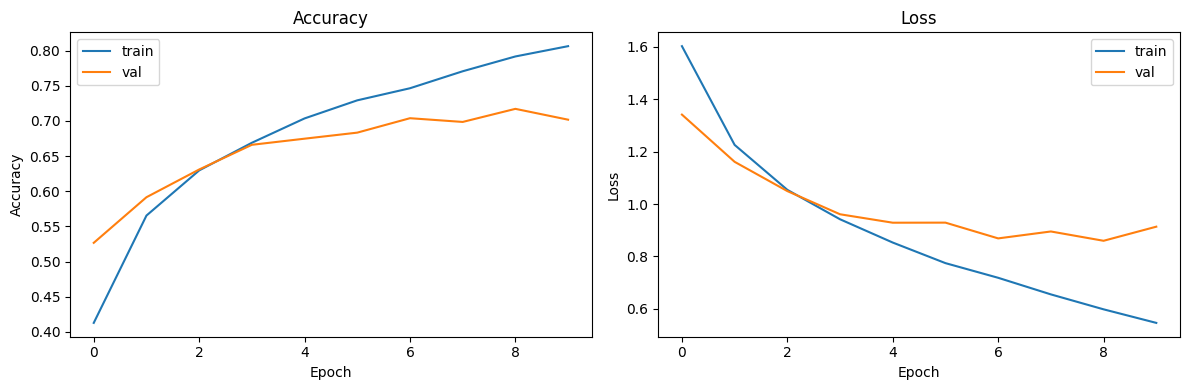

In [5]:
# 9. Graficar pérdida y accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

| Métrica          | Qué indica                                                                |
| ---------------- | ------------------------------------------------------------------------- |
| **loss**         | Error del modelo en los datos de entrenamiento                            |
| **accuracy**     | Qué porcentaje de predicciones correctas tiene el modelo en entrenamiento |
| **val_loss**     | Error en el conjunto de validación                                        |
| **val_accuracy** | Qué tan bien generaliza el modelo a datos no usados para entrenar         |


Observamos que el modelo mejora continuamente en el conjunto de entrenamiento, pero su desempeño en validación se estabiliza, lo que indica que comienza a sobreajustar y pierde capacidad de generalización.

Recomendacion: Agregar un Dropout

In [6]:
model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [7]:
# 5. Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Y en el entrenamiento un EarlyStopping

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6462 - loss: 1.0101 - val_accuracy: 0.6755 - val_loss: 0.9388
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 109ms/step - accuracy: 0.6683 - loss: 0.9483 - val_accuracy: 0.6767 - val_loss: 0.9194
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.6844 - loss: 0.8984 - val_accuracy: 0.6832 - val_loss: 0.9063
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 101ms/step - accuracy: 0.7040 - loss: 0.8404 - val_accuracy: 0.6868 - val_loss: 0.9063
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.7206 - loss: 0.7949 - val_accuracy: 0.7057 - val_loss: 0.8676
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.7351 - loss: 0.7553 - val_accuracy: 0.7007 - val_loss: 0.8720
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7488 - loss: 0.7129 - val_accuracy: 0.7091 - val_loss: 0.8537
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.7593 - loss: 0.

In [10]:
# 8. Evaluar
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nAccuracy en test: {test_acc:.4f}")


Accuracy en test: 0.7101


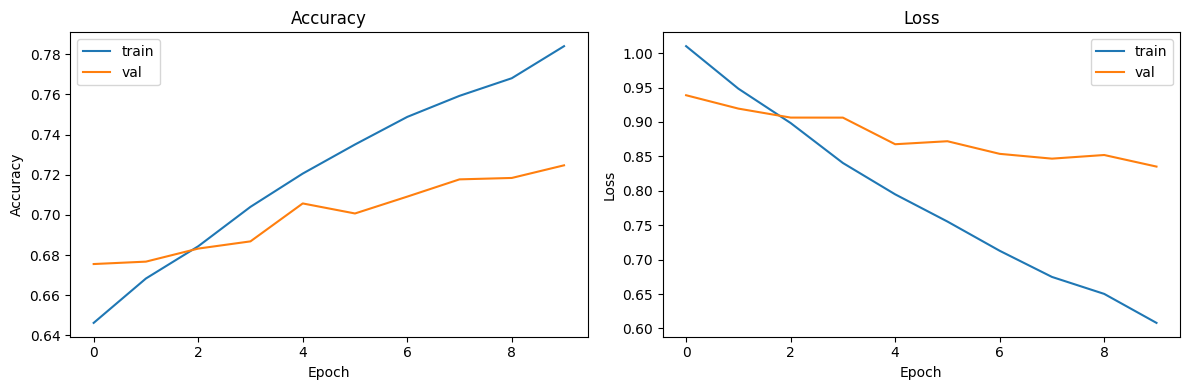

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Al incorporar dropout, el modelo reduce su dependencia de combinaciones específicas de neuronas, lo que disminuye el sobreajuste. Esto se refleja en una menor diferencia entre entrenamiento y validación, logrando una mejor capacidad de generalización.

| Sin Dropout           | Con Dropout             |
| --------------------- | ----------------------- |
| Más accuracy en train | Menos accuracy en train |
| Más overfitting       | Mejor generalización    |


Qué esperarías después de esto:

* No necesariamente que el train accuracy sea más alto. De hecho, a veces baja un poco.
* Pero sí esperarías:

   - menor brecha entre train y val
   - val loss más estable
   - mejor generalización

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


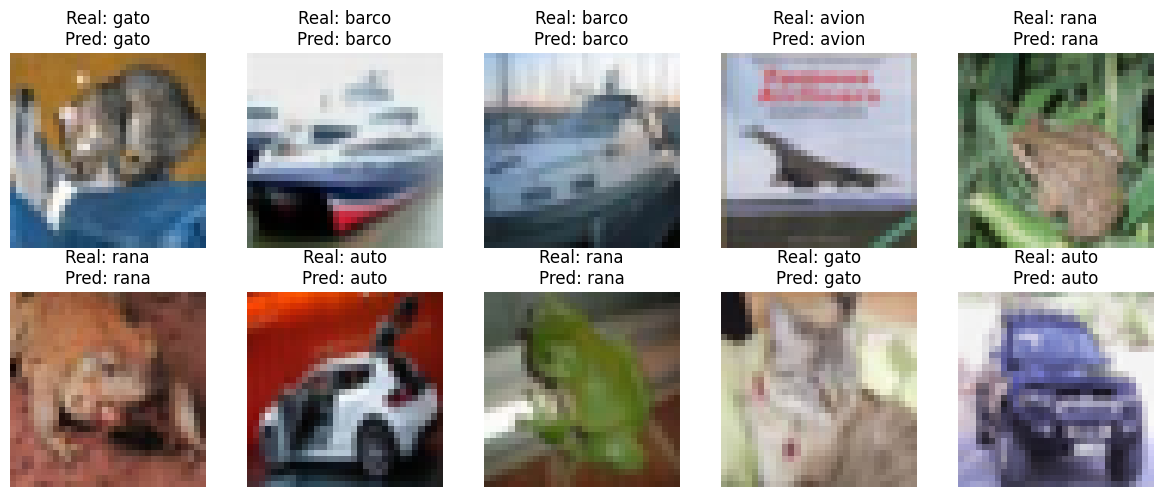

In [12]:
# 10. Predicciones de ejemplo
predictions = model.predict(x_test[:10]) # Genera las probabilidades de clase para las primeras 10 imágenes
pred_classes = np.argmax(predictions, axis=1) # Toma la clase con mayor probabilidad para cada imagen

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i][0]]
    pred = class_names[pred_classes[i]]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# **PARTE 2**

**augmentation dentro del modelo**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    # Data Augmentation
    layers.RandomRotation(0.1),          # rota aprox. ±10%
    layers.RandomFlip("horizontal"),     # volteo horizontal
    layers.RandomZoom(0.1),              # zoom in/out

    # CNN
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

**EarlyStopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

| Parámetro            | Qué significa                                   |
| -------------------- | ----------------------------------------------- |
| monitor              | métrica que se observa (normalmente `val_loss`) |
| patience             | cuántas epochs esperar sin mejora               |
| restore_best_weights | recupera los pesos de la mejor epoch            |


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

**Ejemplo completo: CNN con EarlyStopping**

Shape x_train: (50000, 32, 32, 3)
Shape y_train: (50000, 1)
Shape x_test : (10000, 32, 32, 3)
Shape y_test : (10000, 1)


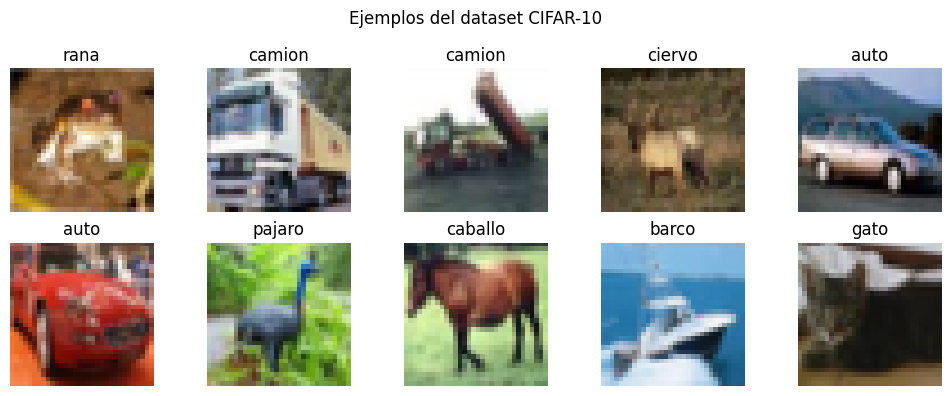

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 102ms/step - accuracy: 0.4189 - loss: 1.5892 - val_accuracy: 0.5233 - val_loss: 1.3203
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.5758 - loss: 1.1895 - val_accuracy: 0.6042 - val_loss: 1.1086
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.6452 - loss: 1.0054 - val_accuracy: 0.6524 - val_loss: 1.0028
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.6894 - loss: 0.8832 - val_accuracy: 0.6816 - val_loss: 0.9202
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7203 - loss: 0.7972 - val_accuracy: 0.6971 - val_loss: 0.8710
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.7510 - loss: 0.7186 - val_accuracy: 0.7022 - val_loss: 0.8841
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7701 - loss: 0.6543 - val_accuracy: 0.6978 - val_loss: 0.8905
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.7949 - loss: 0.

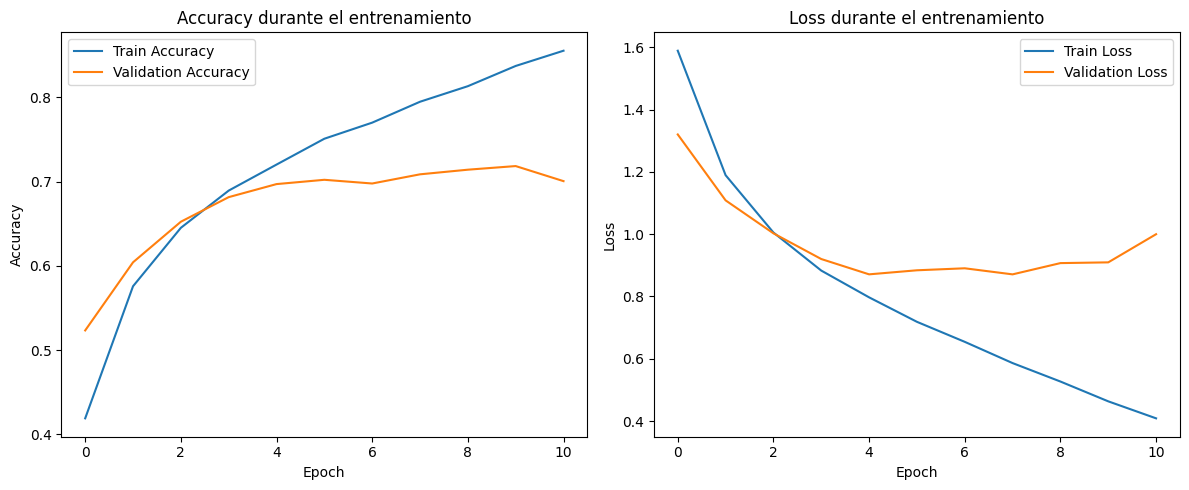

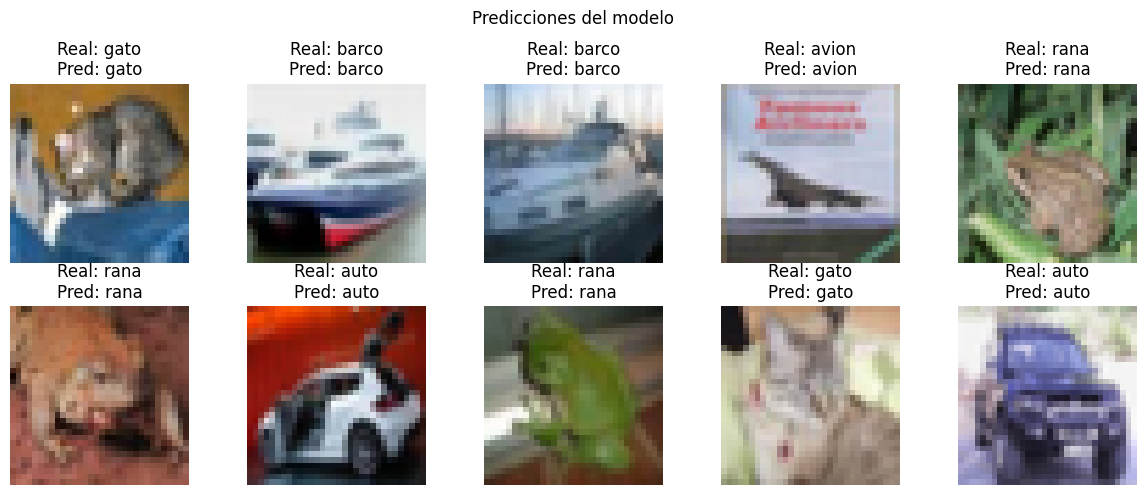

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. Cargar dataset CIFAR-10
# =========================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'avion', 'auto', 'pajaro', 'gato', 'ciervo',
    'perro', 'rana', 'caballo', 'barco', 'camion'
]

print("Shape x_train:", x_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape x_test :", x_test.shape)
print("Shape y_test :", y_test.shape)

# =========================================================
# 2. Normalizar imágenes
# =========================================================
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# =========================================================
# 3. Mostrar algunas imágenes
# =========================================================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Ejemplos del dataset CIFAR-10")
plt.tight_layout()
plt.show()

# =========================================================
# 4. Construir modelo CNN
# =========================================================
model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# =========================================================
# 5. Resumen del modelo
# =========================================================
model.summary()

# =========================================================
# 6. Compilar modelo
# =========================================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 7. Definir EarlyStopping
# =========================================================
early_stop = EarlyStopping(
    monitor='val_loss',          # métrica a observar
    patience=3,                 # esperar 3 epochs sin mejora
    restore_best_weights=True,  # volver a los mejores pesos
    verbose=1
)

# =========================================================
# 8. Entrenar modelo
# =========================================================
history = model.fit(
    x_train, y_train,
    epochs=30,                  # ponemos más epochs a propósito
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# 9. Evaluar en test
# =========================================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nLoss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

# =========================================================
# 10. Mostrar cuántas epochs realmente entrenó
# =========================================================
epochs_trained = len(history.history['loss'])
print(f"\nEl entrenamiento se detuvo en la epoch: {epochs_trained}")

# =========================================================
# 11. Graficar curvas de entrenamiento
# =========================================================
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss durante el entrenamiento')
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 12. Hacer algunas predicciones
# =========================================================
predictions = model.predict(x_test[:10], verbose=0)
pred_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i][0]]
    pred = class_names[pred_classes[i]]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")

plt.suptitle("Predicciones del modelo")
plt.tight_layout()
plt.show()

**Ejemplo simple con VGG16**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # congelamos la base convolucional

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()